In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from scipy.spatial.distance import cdist
from scipy.sparse import csr_matrix
from scipy.sparse.csgraph import connected_components

RAW = '../data/01_raw/'
train = pd.read_csv(RAW + 'train_raw.csv').dropna(subset=['protein_sequence', 'tm']).copy()
train['seq_len'] = train['protein_sequence'].str.len()
print(f'train: {len(train)} sequences')

train: 31390 sequences


In [2]:
MAX_MUTATIONS = 10

def find_cluster_edges(seqs, max_mutations):
    n = len(seqs)
    if n < 2:
        return []
    L = len(seqs[0])
    mat = np.frombuffer(b''.join(s.encode('ascii') for s in seqs), dtype=np.uint8).reshape(n, L)
    dists = (cdist(mat, mat, metric='hamming') * L).astype(int)
    ii, jj = np.where((dists > 0) & (dists <= max_mutations))
    mask = ii < jj
    return list(zip(ii[mask].tolist(), jj[mask].tolist(), dists[ii[mask], jj[mask]].tolist()))

all_edges = []
for length, group in train.groupby('seq_len'):
    if len(group) < 2:
        continue
    seqs = group['protein_sequence'].tolist()
    local_edges = find_cluster_edges(seqs, MAX_MUTATIONS)
    if local_edges:
        global_idx = group.index.tolist()
        for li, lj, nm in local_edges:
            all_edges.append((global_idx[li], global_idx[lj], nm))

n_seqs = len(train)
idx_map = {v: i for i, v in enumerate(train.index)}
if all_edges:
    rows = [idx_map[e[0]] for e in all_edges]
    cols = [idx_map[e[1]] for e in all_edges]
    d = [1] * len(all_edges)
    graph = csr_matrix((d + d, (rows + cols, cols + rows)), shape=(n_seqs, n_seqs))
    n_components, labels = connected_components(graph, directed=False)
else:
    n_components, labels = n_seqs, np.arange(n_seqs)

train['cluster_id'] = labels
cluster_sizes = pd.Series(labels).value_counts()
multi_clusters = cluster_sizes[cluster_sizes > 1]
clustered = train[train['cluster_id'].isin(multi_clusters.index)].copy()
print(f'clusters with >1 sequence: {len(multi_clusters)}, sequences: {multi_clusters.sum()}')

clusters with >1 sequence: 312, sequences: 7100


In [3]:
records = []
for cid, group in clustered.groupby('cluster_id'):
    wt_seq = group.loc[group['tm'].idxmax(), 'protein_sequence']
    for _, row in group.iterrows():
        s = row['protein_sequence']
        if len(s) == len(wt_seq):
            records.append({
                'cluster_id': cid,
                'n_mutations': sum(a != b for a, b in zip(s, wt_seq)),
            })
mut_df = pd.DataFrame(records)
print(mut_df['n_mutations'].value_counts().sort_index().rename('sequences').to_frame())

             sequences
n_mutations           
0                  445
1                  380
2                 6175
3                   12
4                    9
5                    7
6                    7
7                    8
8                   13
9                   39
10                   5


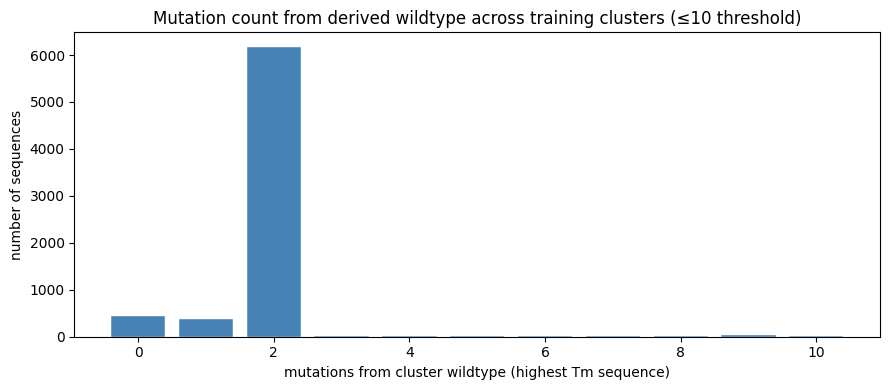

In [4]:
counts = mut_df['n_mutations'].value_counts().sort_index()
fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(counts.index, counts.values, color='steelblue', edgecolor='white', linewidth=0.3)
ax.set_xlabel('mutations from cluster wildtype (highest Tm sequence)')
ax.set_ylabel('number of sequences')
ax.set_title(f'Mutation count from derived wildtype across training clusters (≤{MAX_MUTATIONS} threshold)')
ax.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))
plt.tight_layout()
plt.show()